In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
data = pd.read_csv('DS-4002-sp26-survey-results.csv')

In [10]:
data.columns

Index(['Timestamp', 'Are you a full-time undergraduate UVA student?',
       'What year are you?', 'Do you believe a hotdog is a sandwich?'],
      dtype='object')

In [9]:
data.isna().sum()

Timestamp                                         0
Are you a full-time undergraduate UVA student?    0
What year are you?                                0
Do you believe a hotdog is a sandwich?            0
dtype: int64

In [ ]:
print(data.head())
print("\nData shape:", data.shape)
print("\nData types:")
print(data.dtypes)

            Timestamp Are you a full-time undergraduate UVA student?  \
0  1/14/2026 14:54:44                                            Yes   
1  1/14/2026 14:55:14                                            Yes   
2  1/14/2026 14:56:49                                            Yes   
3  1/14/2026 14:58:15                                            Yes   
4  1/14/2026 14:58:25                                            Yes   

  What year are you? Do you believe a hotdog is a sandwich?  
0                3rd                                     No  
1                4th                                     No  
2                4th                                     No  
3                4th                                    Yes  
4                4th                                    Yes  

Data shape: (79, 4)

Data types:
Timestamp                                         object
Are you a full-time undergraduate UVA student?    object
What year are you?                             

In [14]:
data.drop(data[data['Are you a full-time undergraduate UVA student?'] == 'No'].index, inplace=True)

In [15]:
data.shape

(76, 4)

## Potential Bias Analysis

### 1. **Selection Bias**
- Survey conducted on UVA students only - may not represent broader population
- Self-selection: people with strong opinions about hot dogs more likely to respond

### 2. **Response Bias**
- Leading questions could bias responses toward particular answers
- Social desirability bias: respondents may answer based on perceived "correct" opinion
- Potential for joke/satirical responses given the seemingly trivial topic

### 3. **Coverage Bias**
- Limited to UVA community (academic, affluent, younger demographic)
- Geographic bias: Virginia/Southeast preferences not representative nationally
- Socioeconomic status likely skewed toward college-educated, middle+ income

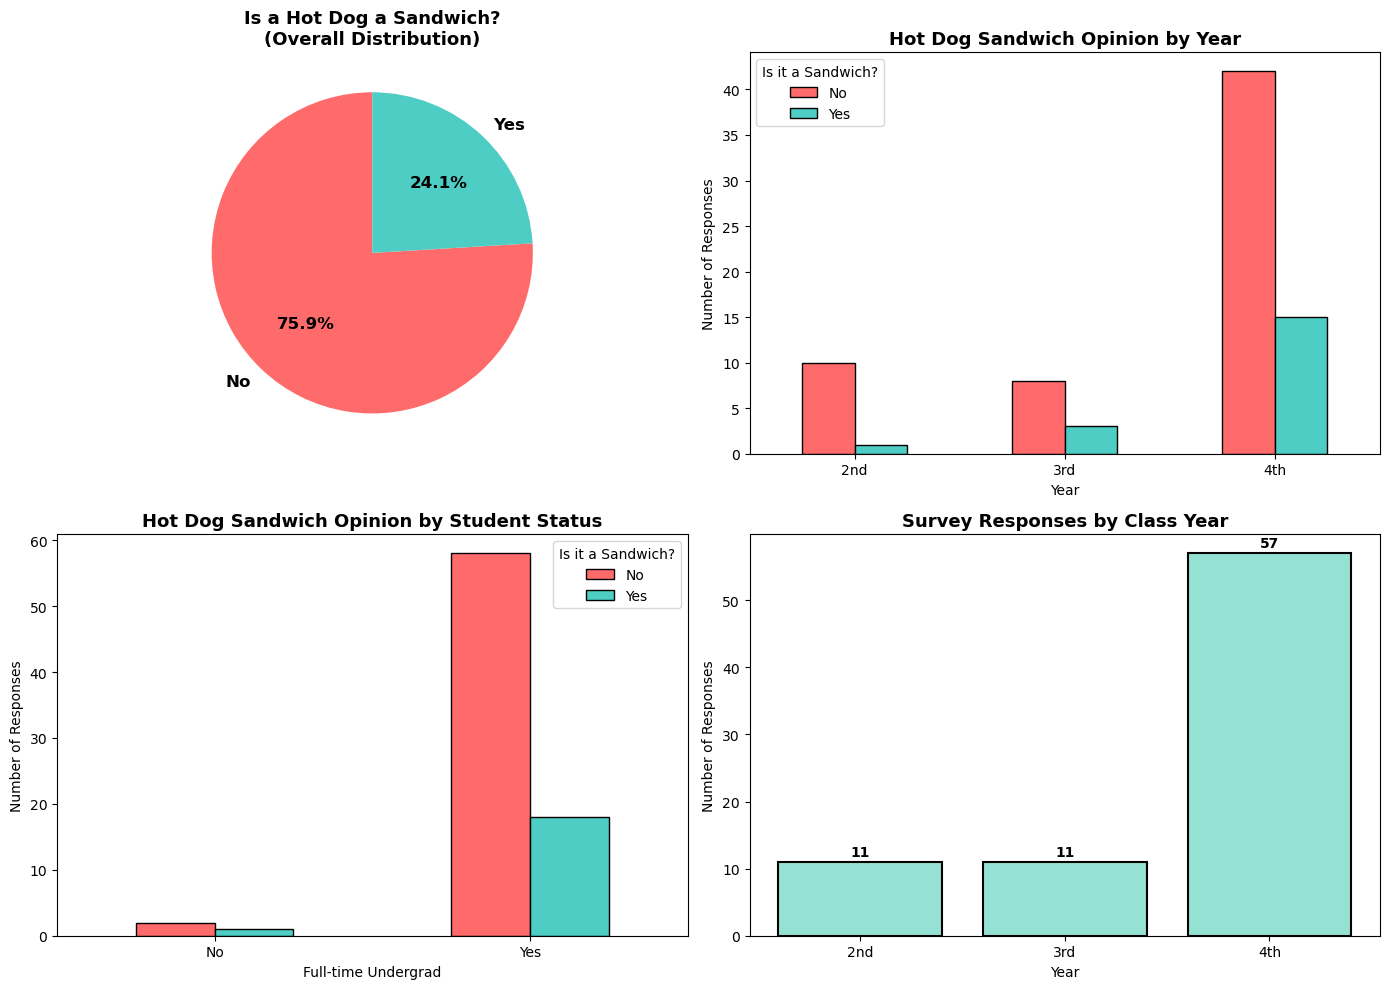


SURVEY SUMMARY STATISTICS

Total Responses: 79

Full-time UVA Students: 76
Non-students/Part-time: 3

--- Hot Dog is a Sandwich? ---
Yes: 19 (24.1%)
No: 60 (75.9%)

--- Breakdown by Year ---
2nd Year: 11 responses (1 think it's a sandwich - 9.1%)
3rd Year: 11 responses (3 think it's a sandwich - 27.3%)
4th Year: 57 responses (15 think it's a sandwich - 26.3%)


In [13]:
# Survey Results Analysis

# 1. Main Question: Is a hot dog a sandwich?
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Overall distribution - Hot dog is sandwich
sandwich_counts = data['Do you believe a hotdog is a sandwich?'].value_counts()
colors_sandwich = ['#ff6b6b', '#4ecdc4']
axes[0, 0].pie(sandwich_counts.values, labels=sandwich_counts.index, autopct='%1.1f%%', 
               colors=colors_sandwich, startangle=90, textprops={'fontsize': 12, 'weight': 'bold'})
axes[0, 0].set_title('Is a Hot Dog a Sandwich?\n(Overall Distribution)', fontsize=13, weight='bold')

# Plot 2: Hot dog opinion by year
year_sandwich = pd.crosstab(data['What year are you?'], data['Do you believe a hotdog is a sandwich?'])
year_sandwich.plot(kind='bar', ax=axes[0, 1], color=['#ff6b6b', '#4ecdc4'], edgecolor='black')
axes[0, 1].set_title('Hot Dog Sandwich Opinion by Year', fontsize=13, weight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Number of Responses')
axes[0, 1].legend(title='Is it a Sandwich?', labels=['No', 'Yes'])
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=0)

# Plot 3: Hot dog opinion by student status
student_sandwich = pd.crosstab(data['Are you a full-time undergraduate UVA student?'], 
                                data['Do you believe a hotdog is a sandwich?'])
student_sandwich.plot(kind='bar', ax=axes[1, 0], color=['#ff6b6b', '#4ecdc4'], edgecolor='black')
axes[1, 0].set_title('Hot Dog Sandwich Opinion by Student Status', fontsize=13, weight='bold')
axes[1, 0].set_xlabel('Full-time Undergrad')
axes[1, 0].set_ylabel('Number of Responses')
axes[1, 0].legend(title='Is it a Sandwich?', labels=['No', 'Yes'])
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=0)

# Plot 4: Response distribution by year
year_counts = data['What year are you?'].value_counts().sort_index()
axes[1, 1].bar(year_counts.index, year_counts.values, color='#95e1d3', edgecolor='black', linewidth=1.5)
axes[1, 1].set_title('Survey Responses by Class Year', fontsize=13, weight='bold')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Number of Responses')
for i, v in enumerate(year_counts.values):
    axes[1, 1].text(i, v + 0.5, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*60)
print("SURVEY SUMMARY STATISTICS")
print("="*60)
print(f"\nTotal Responses: {len(data)}")
print(f"\nFull-time UVA Students: {(data['Are you a full-time undergraduate UVA student?'] == 'Yes').sum()}")
print(f"Non-students/Part-time: {(data['Are you a full-time undergraduate UVA student?'] == 'No').sum()}")

print(f"\n--- Hot Dog is a Sandwich? ---")
print(f"Yes: {(data['Do you believe a hotdog is a sandwich?'] == 'Yes').sum()} ({(data['Do you believe a hotdog is a sandwich?'] == 'Yes').sum()/len(data)*100:.1f}%)")
print(f"No: {(data['Do you believe a hotdog is a sandwich?'] == 'No').sum()} ({(data['Do you believe a hotdog is a sandwich?'] == 'No').sum()/len(data)*100:.1f}%)")

print(f"\n--- Breakdown by Year ---")
for year in sorted(data['What year are you?'].unique()):
    count = len(data[data['What year are you?'] == year])
    yes_count = len(data[(data['What year are you?'] == year) & (data['Do you believe a hotdog is a sandwich?'] == 'Yes')])
    print(f"{year} Year: {count} responses ({yes_count} think it's a sandwich - {yes_count/count*100:.1f}%)")